In [27]:
# Case Study 1: Missing Value Imputation
# Load Iris dataset and introduce NaN values every 10th row.
# Then compare mean, median, and most_frequent imputation.

import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.impute import SimpleImputer

# Load Iris dataset
iris = load_iris()

X = pd.DataFrame(iris.data,columns=iris.feature_names)

# Introduce NaN values in every 10th row
X_nan = X.copy()

X_nan.iloc[::10, :] = np.nan

print("Original data:")
print(X.head(15))

print("\nData with NaN values:")
print(X_nan.head(15))


# Mean Imputation.

mean_imputer = SimpleImputer(strategy="mean")

X_mean = mean_imputer.fit_transform(X_nan)

X_mean = pd.DataFrame(X_mean,columns=iris.feature_names)

print("Mean Imputation:")
print(X_mean.head(15))


# Median Imputation.

median_imputer = SimpleImputer(strategy="median")

X_median = median_imputer.fit_transform(X_nan)

X_median = pd.DataFrame(X_median,columns=iris.feature_names)

print("Median Imputation:")
print(X_median.head(15))


# Most Frequent Imputation.


freq_imputer = SimpleImputer(strategy="most_frequent")

X_freq = freq_imputer.fit_transform(X_nan)

X_freq = pd.DataFrame(X_freq,columns=iris.feature_names)

print("Most Frequent Imputation:")
print(X_freq.head(15))


# Calculate the percentage of values that were changed
# during imputation.

total_values = X_nan.size
missing_values = X_nan.isna().sum().sum()

percentage_changed = (missing_values / total_values) * 100

print("Total values:", total_values)
print("Missing values:", missing_values)
print("Percentage of values changed:", percentage_changed, "%")




Original data:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                 5.1               3.5                1.4               0.2
1                 4.9               3.0                1.4               0.2
2                 4.7               3.2                1.3               0.2
3                 4.6               3.1                1.5               0.2
4                 5.0               3.6                1.4               0.2
5                 5.4               3.9                1.7               0.4
6                 4.6               3.4                1.4               0.3
7                 5.0               3.4                1.5               0.2
8                 4.4               2.9                1.4               0.2
9                 4.9               3.1                1.5               0.1
10                5.4               3.7                1.5               0.2
11                4.8               3.4                1.6   

1. When should you use median vs. mean?

Mean: لما البيانات مفيهاش outliers قوية والتوزيع قريب من الطبيعي.
Median: لما البيانات فيها outliers أو distribution مش symmetric.

2. Why fit_transform() instead of fit() + transform()?

fit() بتتعلم الإحصائيات من البيانات، مثل الـ mean.

transform() بتستخدم الإحصائيات دي لتحويل البيانات.

fit_transform() بتعمل الاتنين مع بعض في خطوة واحدة.




In [28]:
# Extension: KNNImputer

from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

X_knn = knn_imputer.fit_transform(X_nan)

X_knn = pd.DataFrame(X_knn,columns=iris.feature_names)

print("KNN Imputation:")
print(X_knn.head(15))

KNN Imputation:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0            5.837778          3.054815           3.751852          1.194074
1            4.900000          3.000000           1.400000          0.200000
2            4.700000          3.200000           1.300000          0.200000
3            4.600000          3.100000           1.500000          0.200000
4            5.000000          3.600000           1.400000          0.200000
5            5.400000          3.900000           1.700000          0.400000
6            4.600000          3.400000           1.400000          0.300000
7            5.000000          3.400000           1.500000          0.200000
8            4.400000          2.900000           1.400000          0.200000
9            4.900000          3.100000           1.500000          0.100000
10           5.837778          3.054815           3.751852          1.194074
11           4.800000          3.400000           1.600000  

Original data:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0   

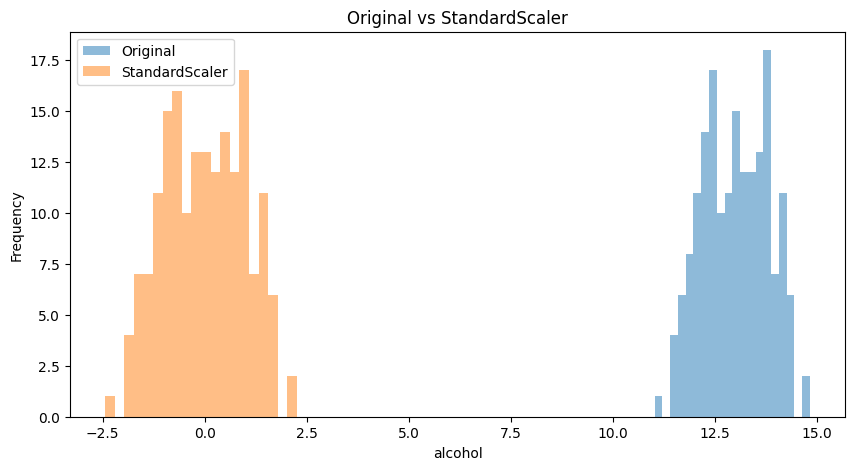

In [29]:
# Case Study 2: Feature Scaling
# Load Wine dataset and apply StandardScaler,
# MinMaxScaler, and RobustScaler.

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

wine = load_wine()

X = pd.DataFrame(wine.data,columns=wine.feature_names)

print("Original data:")
print(X.head())

# StandardScaler.

standard_scaler = StandardScaler()

X_standard = standard_scaler.fit_transform(X)

X_standard = pd.DataFrame(X_standard,columns=wine.feature_names)

# MinMaxScaler.

minmax_scaler = MinMaxScaler()

X_minmax = minmax_scaler.fit_transform(X)

X_minmax = pd.DataFrame(X_minmax,columns=wine.feature_names)


# Apply RobustScaler.
# Scaling is based on median and interquartile range (IQR).

robust_scaler = RobustScaler()

X_robust = robust_scaler.fit_transform(X)

X_robust = pd.DataFrame(X_robust,columns=wine.feature_names)


# Compare standard deviations before and after scaling.

print("Original standard deviations:")
print(X.std())

print("\nStandardScaler standard deviations:")
print(X_standard.std())

print("\nMinMaxScaler standard deviations:")
print(X_minmax.std())

print("\nRobustScaler standard deviations:")
print(X_robust.std())


# Plot the original and scaled distribution of the first feature.

feature = wine.feature_names[0]

plt.figure(figsize=(10, 5))

plt.hist(X[feature], bins=20, alpha=0.5, label="Original")
plt.hist(X_standard[feature], bins=20, alpha=0.5, label="StandardScaler")

plt.xlabel(feature)
plt.ylabel("Frequency")
plt.title("Original vs StandardScaler")
plt.legend()

plt.show()


Why StandardScaler doesn't guarantee [0,1]?

لأن StandardScaler بيعمل:

x - mean
---------
  std

فالقيم ممكن تكون:

-2
-1
0
1
2

مش لازم تكون بين 0 و1.

When RobustScaler outperform others?

لما يكون عندك outliers كتير.

لأنه بيعتمد على:

Median
IQR

بدل mean وstandard deviation.

In [30]:
# Extension:  Standard Scaling followed by PCA.

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])

X_pca = pipeline.fit_transform(X)

print("PCA shape:")
print(X_pca.shape)

PCA shape:
(178, 2)


Logistic Regression:
[[41  1]
 [ 1 71]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Random Forest:
[[39  3]
 [ 2 70]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Logistic Regression AUC: 0.9953703703703703
Random Forest AUC: 0.9937169312169312


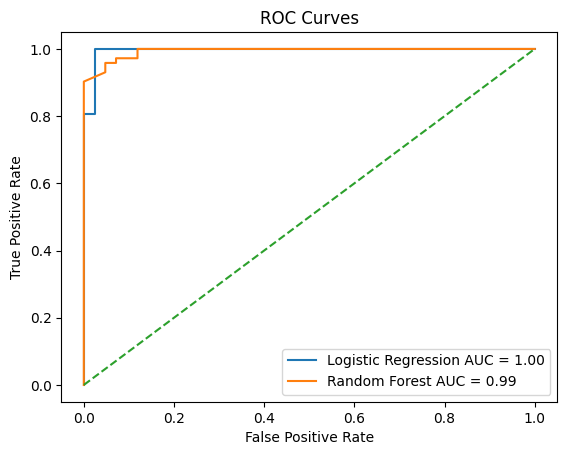

In [31]:
# Case Study 3: Classification Metrics
# Load the Breast Cancer dataset,
# split it into training and testing data,
# and train Logistic Regression and Random Forest.

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



# Scale the data because Logistic Regression
# can benefit from feature scaling.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model.

logistic = LogisticRegression(max_iter=5000)

logistic.fit(X_train_scaled, y_train)

y_pred_logistic = logistic.predict(X_test_scaled)
y_prob_logistic = logistic.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression:")
print(confusion_matrix(y_test, y_pred_logistic))
print(classification_report(y_test, y_pred_logistic))


# Train a Random Forest classifier.

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


# Calculate ROC curves and AUC scores
# for both classifiers.

fpr_logistic, tpr_logistic, _ = roc_curve(y_test,y_prob_logistic)

fpr_rf, tpr_rf, _ = roc_curve(y_test,y_prob_rf)

auc_logistic = roc_auc_score(y_test,y_prob_logistic)

auc_rf = roc_auc_score(y_test,y_prob_rf)

print("Logistic Regression AUC:", auc_logistic)
print("Random Forest AUC:", auc_rf)

# Plot ROC curves for both classifiers.

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression AUC = {auc_logistic:.2f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC = {auc_rf:.2f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend()
plt.show()

Why recall may be more important for cancer diagnosis?

لأننا عايزين نقلل False Negatives.

يعني مريض عنده cancer والـ model يقول إنه سليم.

ده أخطر من إن الـ model يقول لشخص سليم إنه محتاج فحص إضافي.

What does AUC = 0.5 indicate?

يعني الـ model تقريبًا مش قادر يفرق بين classes.

AUC = 1.0 → excellent
AUC = 0.5 → random guessing
AUC < 0.5 → worse than random

In [32]:
# Extension: Use Stratified K-Fold Cross Validation

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    logistic,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring="f1"
)

print("F1 scores:")
print(scores)

print("Mean F1:")
print(scores.mean())

F1 scores:
[0.97435897 0.99115044 0.98245614 0.99130435 0.97345133]
Mean F1:
0.9825442464894886


In [33]:
# Case Study 4: Feature Selection
# Use SelectKBest with mutual information and f-regression,
# then use RFE with Linear Regression.

from sklearn.datasets import load_diabetes

from sklearn.feature_selection import (SelectKBest, mutual_info_regression,f_regression)

from sklearn.feature_selection import RFE

from sklearn.linear_model import LinearRegression

data = load_diabetes()

X = data.data
y = data.target

feature_names = data.feature_names

print("Feature names:")
print(feature_names)



# Select the 5 best features using Mutual Information.

selector_mi = SelectKBest(
    score_func=mutual_info_regression,
    k=5
)

X_mi = selector_mi.fit_transform(X, y)

selected_mi = [
    feature_names[i]
    for i in range(len(feature_names))
    if selector_mi.get_support()[i]
]

print("Selected features using Mutual Information:")
print(selected_mi)


# Select the 5 best features using F-regression.

selector_f = SelectKBest(
    score_func=f_regression,
    k=5
)

X_f = selector_f.fit_transform(X, y)

selected_f = [
    feature_names[i]
    for i in range(len(feature_names))
    if selector_f.get_support()[i]
]

print("Selected features using F-regression:")
print(selected_f)


# Apply Recursive Feature Elimination using Linear Regression.
# RFE repeatedly removes the least important features.

model = LinearRegression()

rfe = RFE(
    estimator=model,
    n_features_to_select=5
)

X_rfe = rfe.fit_transform(X, y)

selected_rfe = [
    feature_names[i]
    for i in range(len(feature_names))
    if rfe.support_[i]
]

print("Selected features using RFE:")
print(selected_rfe)


# Compare Linear Regression using all features
# versus selected features.

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Original features
model_original = LinearRegression()

model_original.fit(X_train, y_train)

pred_original = model_original.predict(X_test)

r2_original = r2_score(
    y_test,
    pred_original
)

# Selected features using RFE
selected_indices = rfe.get_support()

X_selected = X[:, selected_indices]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

model_selected = LinearRegression()

model_selected.fit(X_train_s, y_train_s)

pred_selected = model_selected.predict(X_test_s)

r2_selected = r2_score(
    y_test_s,
    pred_selected
)

print("R2 using all features:", r2_original)
print("R2 using selected features:", r2_selected)


Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Selected features using Mutual Information:
['bmi', 's3', 's4', 's5', 's6']
Selected features using F-regression:
['bmi', 'bp', 's3', 's4', 's5']
Selected features using RFE:
['bmi', 'bp', 's1', 's2', 's5']
R2 using all features: 0.4526027629719195
R2 using selected features: 0.43820139338997743


Why RFE takes longer than SelectKBest?

SelectKBest بيعمل ranking مرة واحدة.

لكن RFE بيعمل:

Train model
↓
Remove features
↓
Train again
↓
Remove features
↓
...

فبيحتاج وقت أكبر.

How does feature selection impact interpretability?

لما نقلل عدد الـ features، بيبقى أسهل نفهم:

إيه أهم features؟
إيه اللي بيأثر على prediction؟
إيه اللي model بيعتمد عليه؟

In [34]:
# Extension: Calculate permutation importance
# to identify important features.

from sklearn.inspection import permutation_importance

model = LinearRegression()

model.fit(X, y)

importance = permutation_importance(
    model,
    X,
    y,
    random_state=42
)

for name, value in zip(
    feature_names,
    importance.importances_mean
):
    print(name, value)

age -7.73968768965183e-05
sex 0.04311262464250236
bmi 0.21613216892526027
bp 0.07387381526385237
s1 0.4918708724177723
s2 0.1607950752172571
s3 0.009759039187358366
s4 0.021234142884470408
s5 0.4210099772086198
s6 0.0031181156713335546


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  
0     15.3  396.90   4.98  
1     17.8  396.90   9.14  
2     17.8  392.83   4.03  
3     18.7  394.63   2.94  
4     18.7  396.90   5.33  


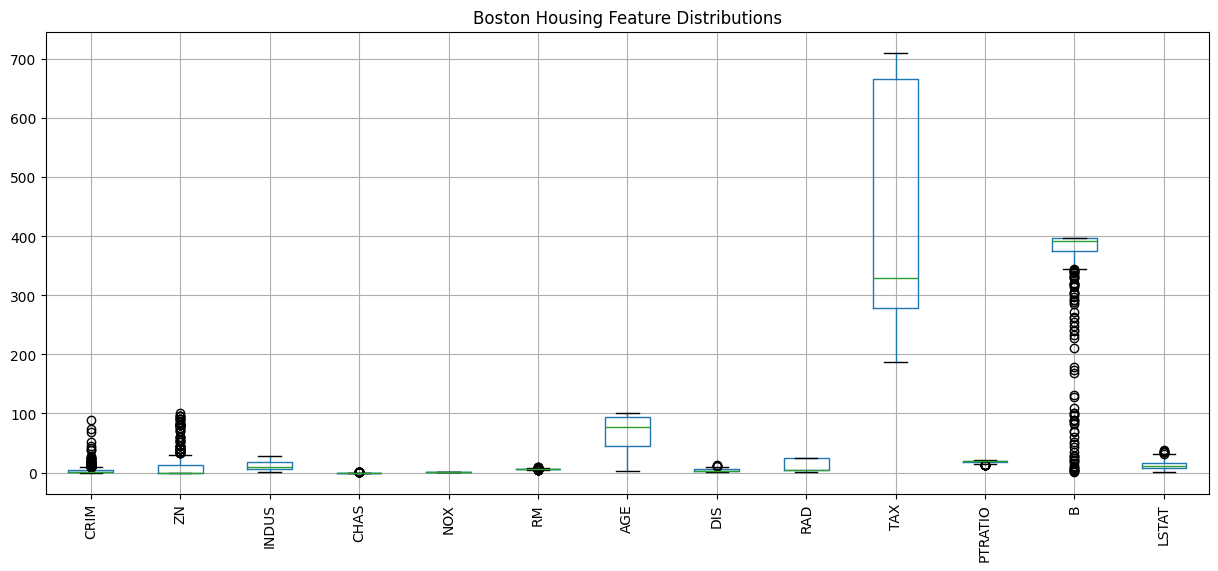

Number of outliers per feature:
CRIM        8
ZN         14
INDUS       0
CHAS       35
NOX         0
RM          8
AGE         0
DIS         5
RAD         0
TAX         0
PTRATIO     0
B          25
LSTAT       5
dtype: int64
Isolation Forest labels:
[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1
 -1 -1  1  1  1  1  1  1 -1  1 -1 -1 -1  1  1  1  1  1 -1 -1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1

In [35]:
# Case Study 5: Outlier Handling
# Load the Boston Housing dataset from OpenML.

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

boston = fetch_openml(
    name="boston",
    version=1,
    as_frame=True
)

X = boston.data

# Convert all columns to numeric, coercing errors to NaN
X = X.apply(pd.to_numeric, errors='coerce')

print(X.head())


# Visualize feature distributions using boxplots.

X.boxplot(figsize=(15, 6))

plt.title("Boston Housing Feature Distributions")
plt.xticks(rotation=90)

plt.show()



# Detect outliers using Z-score.
# Values with absolute Z-score greater than 3
# are considered outliers.

from scipy.stats import zscore

z_scores = X.apply(zscore)

outliers_zscore = (abs(z_scores) > 3)

print("Number of outliers per feature:")
print(outliers_zscore.sum())


# Detect outliers using Isolation Forest.

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

outlier_labels = iso.fit_predict(X)

print("Isolation Forest labels:")
print(outlier_labels)

print("\nNumber of outliers:")
print((outlier_labels == -1).sum())


# Keep only normal observations and remove detected outliers.

X_clean = X[outlier_labels == 1]

print("Original shape:")
print(X.shape)

print("Shape after removing outliers:")
print(X_clean.shape)


Why is 3.0 a common Z-score threshold?

لأن في Normal Distribution تقريبًا 99.7% من البيانات بتكون داخل:

mean ± 3 standard deviations

فالقيمة اللي أبعد من 3 standard deviations تعتبر suspicious.

How does contamination affect Isolation Forest?

contamination بتحدد تقريبًا نسبة الـ outliers المتوقعة.

مثلاً:

In [36]:
# Extension: Detect outliers using DBSCAN.

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

print("DBSCAN labels:")
print(labels)

print("\nNumber of outliers:")
print((labels == -1).sum())

DBSCAN labels:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0 -1 -1 -1  0 -1 -1
  0 -1  0 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1  1 -1  1  1  1 -1 -1  1 -1  1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2 -1  2  2 -1  2
  2 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  
Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float6

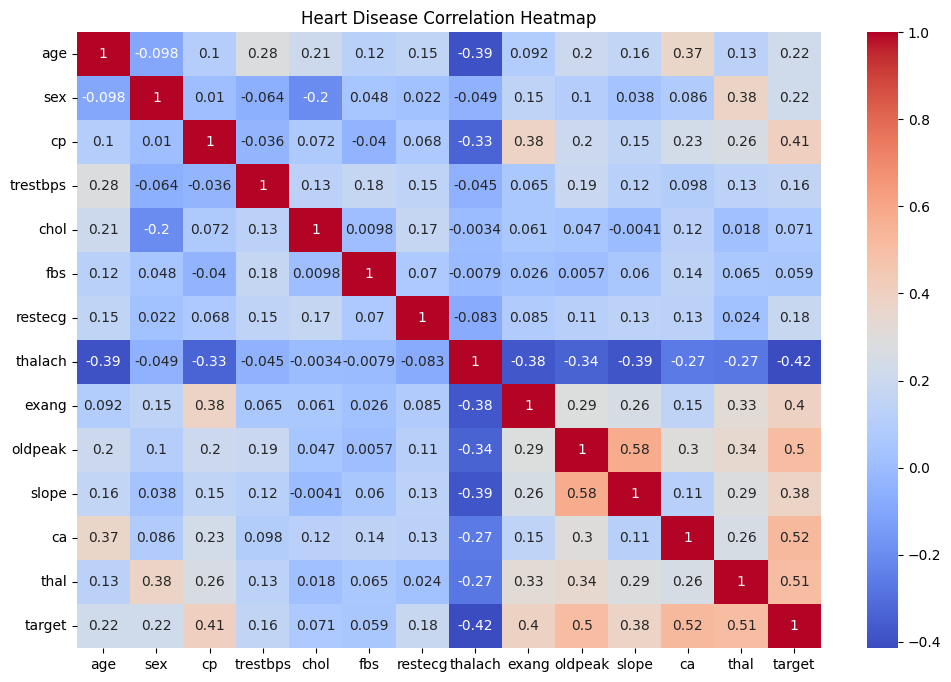

In [37]:
# Case Study 6: Heart Disease
# Load the UCI Heart Disease dataset from a URL.

import pandas as pd
import numpy as np

url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "heart-disease/processed.cleveland.data"
)

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

heart = pd.read_csv(
    url,
    names=columns
)

print(heart.head())

# Replace incorrect entries represented by '?'
# with actual NaN values.

heart = heart.replace("?", np.nan)

print("Missing values:")
print(heart.isnull().sum())


# Convert all columns to numeric values.
# Invalid values become NaN.

for column in heart.columns:
    heart[column] = pd.to_numeric(
        heart[column],
        errors="coerce"
    )

print(heart.dtypes)


# Replace missing numerical values with the median
# of each column.

heart = heart.fillna(heart.median())

print("Missing values after imputation:")
print(heart.isnull().sum())


# Create age groups using binning.

bins = [0, 30, 40, 50, 60, 70, 100]

labels = [
    "Under 30",
    "30-40",
    "40-50",
    "50-60",
    "60-70",
    "70+"
]

heart["age_group"] = pd.cut(
    heart["age"],
    bins=bins,
    labels=labels
)

print(heart[["age", "age_group"]].head(10))


# Apply One-Hot Encoding to categorical variables.

heart_encoded = pd.get_dummies(
    heart,
    columns=["sex", "cp", "fbs", "restecg",
             "exang", "slope", "ca", "thal"],
    drop_first=True
)

print(heart_encoded.head())


# Create a correlation heatmap to understand
# relationships between numerical features.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    heart.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Heart Disease Correlation Heatmap")

plt.show()

Why convert ? to NaN instead of direct imputation?

عشان ? مش قيمة حقيقية.

لو عملنا imputation مباشرة، ممكن الـ model يعتبر ? قيمة رقمية.

الأصح:

? → NaN → Imputation

When should you avoid One-Hot Encoding?

لما يكون عندك high-cardinality categorical feature.

In [38]:
# Extension: Create a simple BMI-like feature.
# Note: The original dataset does not contain height,
# so this is only an example of feature engineering.

heart["chol_age_ratio"] = (
    heart["chol"] / heart["age"]
)

print(heart[["chol", "age", "chol_age_ratio"]].head())

    chol   age  chol_age_ratio
0  233.0  63.0        3.698413
1  286.0  67.0        4.268657
2  229.0  67.0        3.417910
3  250.0  37.0        6.756757
4  204.0  41.0        4.975610


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
dtype: float64
Missing values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Number of duplicate rows:
0
Linear Regression:
MAE: 0.5332001304956553
MSE: 0.5558915986952444
RMSE: 0.7455813830127764
R2: 0.5757877060324508
MAPE: 31.95218741361489 %

Decision Tree:
MAE: 0.45467918846899225
MSE: 0.49523520

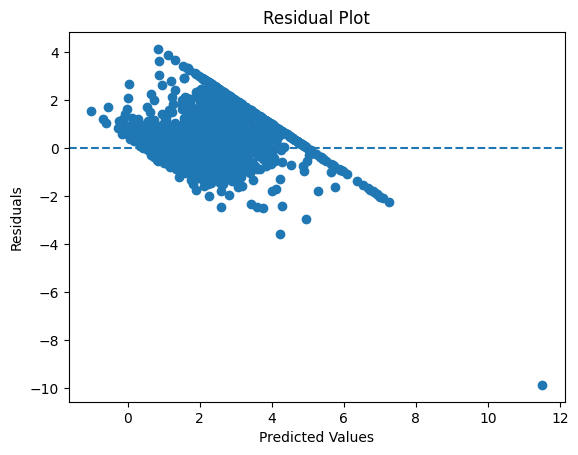

In [39]:
# Case Study 7: Regression Metrics
# Load the California Housing dataset and
# prepare the data for regression.

import pandas as pd

from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

print(X.head())
print(y.head())

# Check for missing values and duplicate rows.

print("Missing values:")
print(X.isnull().sum())

print("\nNumber of duplicate rows:")
print(X.duplicated().sum())


# Split the dataset into training and testing data.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Train a Linear Regression model.

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(X_test)


# Train a Decision Tree Regressor.

from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_pred = tree_model.predict(X_test)


# Calculate MAE, MSE, RMSE, R2, and MAPE
# for both regression models.

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def regression_metrics(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    mape = np.mean(
        np.abs(
            (y_true - y_pred) / y_true
        )
    ) * 100

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("MAPE:", mape, "%")


print("Linear Regression:")
regression_metrics(y_test, linear_pred)

print("\nDecision Tree:")
regression_metrics(y_test, tree_pred)



# Calculate and visualize residuals.
# Residual = Actual value - Predicted value.

residuals = y_test - linear_pred

import matplotlib.pyplot as plt

plt.scatter(
    linear_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Why RMSE is more interpretable than MSE?

لأن:

MSE → squared units
RMSE → original units

What does negative R² indicate?

يعني الـ model أسوأ من baseline بسيط بيستخدم mean of target.

In [40]:
# Extension: Quantile Regression
# Estimate a conditional quantile instead of the mean.

from sklearn.linear_model import QuantileRegressor

quantile_model = QuantileRegressor(
    quantile=0.5,
    alpha=0
)

quantile_model.fit(
    X_train,
    y_train
)

quantile_pred = quantile_model.predict(X_test)

print("Quantile predictions:")
print(quantile_pred[:10])

Quantile predictions:
[0.56188454 1.60830708 2.64013999 2.70873875 2.38949377 1.97563731
 2.48232763 1.9447075  2.78235835 3.82861089]


Dataset shape:
(1797, 64)
Number of selected features:
20
Number of selected features:
20
[0.8777777777777778, 0.95, 0.9694444444444444, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777]


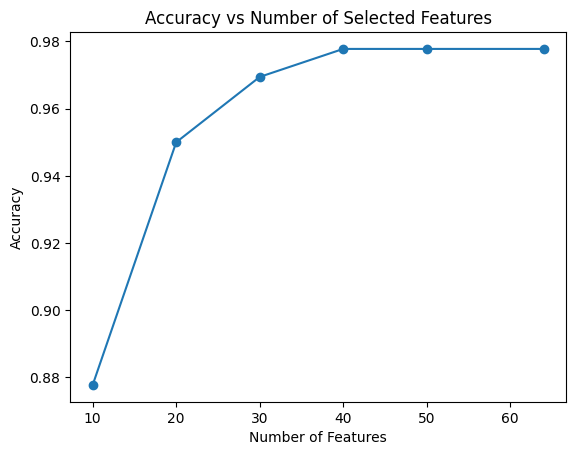

In [41]:
# Case Study 8: Recursive Feature Elimination
# Load the Digits dataset and apply RFE
# using SVM and Random Forest.

from sklearn.datasets import load_digits

from sklearn.feature_selection import RFE

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

data = load_digits()

X = data.data
y = data.target

print("Dataset shape:")
print(X.shape)

# Apply RFE using a Support Vector Machine estimator.
# Select 20 features.

svm = SVC(
    kernel="linear"
)

rfe_svm = RFE(
    estimator=svm,
    n_features_to_select=20,
    step=1
)

X_svm = rfe_svm.fit_transform(
    X,
    y
)

print("Number of selected features:")
print(X_svm.shape[1])


# Apply RFE using Random Forest.
# Select 20 important features.

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rfe_rf = RFE(
    estimator=rf,
    n_features_to_select=20,
    step=1
)

X_rf = rfe_rf.fit_transform(
    X,
    y
)

print("Number of selected features:")
print(X_rf.shape[1])


# Compare classification accuracy using different
# numbers of selected features.

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

feature_numbers = [10, 20, 30, 40, 50, 64]

accuracies = []

for n in feature_numbers:

    rfe = RFE(
        estimator=SVC(kernel="linear"),
        n_features_to_select=n,
        step=1
    )

    X_train_rfe = rfe.fit_transform(
        X_train,
        y_train
    )

    X_test_rfe = rfe.transform(
        X_test
    )

    model = SVC(
        kernel="linear"
    )

    model.fit(
        X_train_rfe,
        y_train
    )

    predictions = model.predict(
        X_test_rfe
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    accuracies.append(accuracy)

print(accuracies)



# Plot accuracy versus number of selected features.

plt.plot(
    feature_numbers,
    accuracies,
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Accuracy")

plt.title(
    "Accuracy vs Number of Selected Features"
)

plt.show()




Why use step=1 in RFE for image data?

لأن كل pixel ممكن يكون مهم.

step=1 بيشيل feature واحدة في كل iteration، وبالتالي selection بيكون أكثر دقة.

How does estimator choice affect feature selection?

كل estimator بيقيس importance بطريقة مختلفة.

مثلاً:

SVM → يعتمد على coefficients
Random Forest → يعتمد على feature importance

لذلك ممكن يختاروا pixels مختلفة.

In [42]:
# Extension: Select important features directly
# from a trained Random Forest model.

from sklearn.feature_selection import SelectFromModel

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

selector = SelectFromModel(
    model,
    prefit=True
)

X_selected = selector.transform(X)

print("Original shape:")
print(X.shape)

print("Selected shape:")
print(X_selected.shape)

Original shape:
(1797, 64)
Selected shape:
(1797, 30)


PCA transformed shape:
(120, 2)


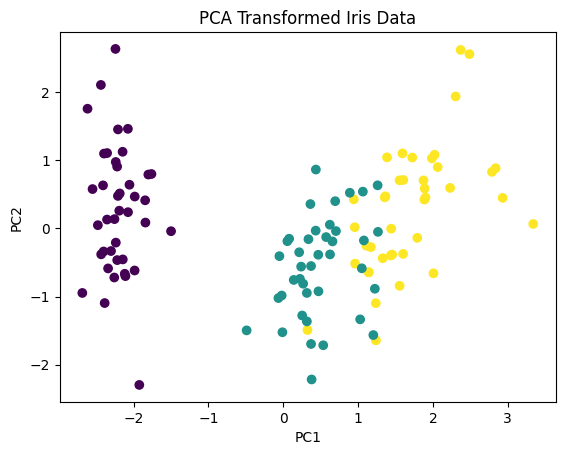

Transformed shape:
(120, 8)


In [43]:
# Case Study 9: Processing Pipeline
# Create an Iris dataset with synthetic missing values,
# then build preprocessing pipelines.

import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X = iris.data.copy()
y = iris.target.copy()

# Add synthetic noise / missing values.
X[::10, 0] = np.nan

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Pipeline 1:
# Imputation → Scaling → PCA

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipeline_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])

X_train_pca = pipeline_pca.fit_transform(
    X_train
)

X_test_pca = pipeline_pca.transform(
    X_test
)

print("PCA transformed shape:")
print(X_train_pca.shape)

# Visualize the two PCA components.

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Transformed Iris Data")

plt.show()


# Pipeline 2:
# Imputation → Polynomial Features → Feature Selection

from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

pipeline_poly = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),

    ("poly", PolynomialFeatures(
        degree=2,
        include_bias=False
    )),

    ("selection", SelectKBest(
        score_func=f_classif,
        k=8
    ))
])

X_train_poly = pipeline_poly.fit_transform(
    X_train,
    y_train
)

X_test_poly = pipeline_poly.transform(
    X_test
)

print("Transformed shape:")
print(X_train_poly.shape)

Questions

Why fit imputer on training data only?

عشان لو عملنا fit على train + test، الـ model هيعرف معلومات من الـ test data.

وده اسمه:

Data Leakage

How does Pipeline prevent data leakage?

Pipeline بتخلي خطوات preprocessing منظمة، ولما نستخدم:

pipeline.fit(X_train, y_train)

كل transformation بيتعمل fitting على training data فقط.

وبعدين:

pipeline.transform(X_test)

الـ test بيتحول باستخدام المعلومات اللي اتعلمناها من training فقط.

In [44]:
# Extension: Create a custom transformer example.
# This transformer clips extreme values instead of removing rows.

from sklearn.base import BaseEstimator, TransformerMixin

class OutlierClipper(
    BaseEstimator,
    TransformerMixin
):

    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.lower_values_ = np.nanpercentile(
            X,
            self.lower * 100,
            axis=0
        )

        self.upper_values_ = np.nanpercentile(
            X,
            self.upper * 100,
            axis=0
        )

        return self

    def transform(self, X):
        return np.clip(
            X,
            self.lower_values_,
            self.upper_values_
        )

In [45]:
# Case Study 10: Categorical Encoding
# Load the Titanic dataset and compare
# different categorical encoding techniques.

import seaborn as sns
import pandas as pd

titanic = sns.load_dataset("titanic")

print(titanic.head())

print("\nCategorical columns:")
print(titanic.select_dtypes(
    include="object"
).columns)


# Handle rare categories by grouping categories
# whose frequency is less than 1% into "Rare".

categorical_columns = titanic.select_dtypes(
    include="object"
).columns

for column in categorical_columns:

    frequency = titanic[column].value_counts(
        normalize=True
    )

    rare_categories = frequency[
        frequency < 0.01
    ].index

    titanic[column] = titanic[column].replace(
        rare_categories,
        "Rare"
    )


# Apply One-Hot Encoding to categorical variables.

titanic_onehot = pd.get_dummies(
    titanic,
    columns=categorical_columns,
    drop_first=True
)

print("One-Hot encoded shape:")
print(titanic_onehot.shape)


# Example of Label Encoding for one categorical column.

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

titanic["sex_encoded"] = encoder.fit_transform(
    titanic["sex"].astype(str)
)

print(
    titanic[
        ["sex", "sex_encoded"]
    ].head()
)


# Train Logistic Regression using the encoded Titanic data.

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Select features
X = titanic[
    [
        "pclass",
        "age",
        "sibsp",
        "parch",
        "fare",
        "sex_encoded"
    ]
]

y = titanic["survived"]

# Fill missing values
imputer = SimpleImputer(
    strategy="median"
)

X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

predictions = model.predict(
    X_test
)

print("Accuracy:")
print(
    accuracy_score(
        y_test,
        predictions
    )
)

# Target Encoding replaces each category
# with the average target value for that category.

titanic_target = titanic.copy()

mean_target = titanic_target.groupby(
    "class"
)["survived"].mean()

titanic_target["class_target_encoded"] = (
    titanic_target["class"]
    .map(mean_target)
)

print(
    titanic_target[
        ["class", "class_target_encoded"]
    ].head()
)


# Simple Binary Encoding example for the "class" column.

class_codes = titanic["class"].astype(
    "category"
).cat.codes

print("Category codes:")
print(class_codes.head())

binary = class_codes.apply(
    lambda x: format(x, "03b")
)

print("\nBinary representation:")
print(binary.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Categorical columns:
Index(['sex', 'embarked', 'who', 'embark_town', 'alive'], dtype='object')
One-Hot encoded shape:
(891, 18)
      sex  sex_encoded
0    male            1
1  female            0
2  female            

/tmp/ipykernel_4003/2812646470.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = titanic_target.groupby(


Why might target encoding cause overfitting?

لأننا بنستخدم الـ target نفسه عشان نعمل encoding.


لو الـ dataset صغيرة، القيمة دي ممكن تكون مبنية على عدد قليل جدًا من observations، وبالتالي model ممكن يحفظ الـ training data بدل ما يتعلم pattern عام.

When should you use hashing vs. binning?

Hashing:

مفيد مع categorical features عندها عدد ضخم جدًا من categories

لأنه مش محتاج يعمل column لكل category.

Binning:

مفيد مع numerical variables لما نحب نحول continuous values إلى groups.

In [48]:
# Extension: CatBoost can handle categorical
# features directly.

!pip install catboost

from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=100,
    verbose=False
)


